In [1]:
import math
import cmath
import numpy as np
import matplotlib.pyplot as plt
import pandas
import japanize_matplotlib

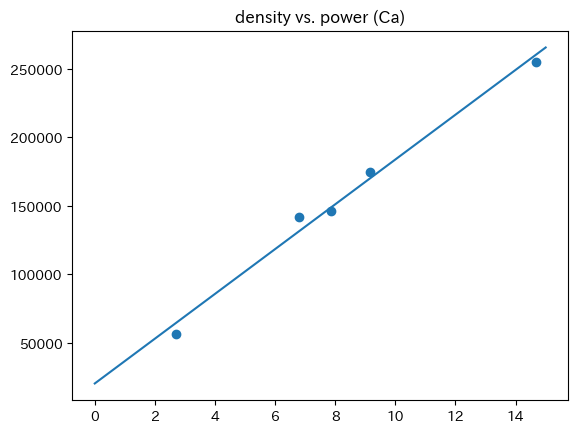

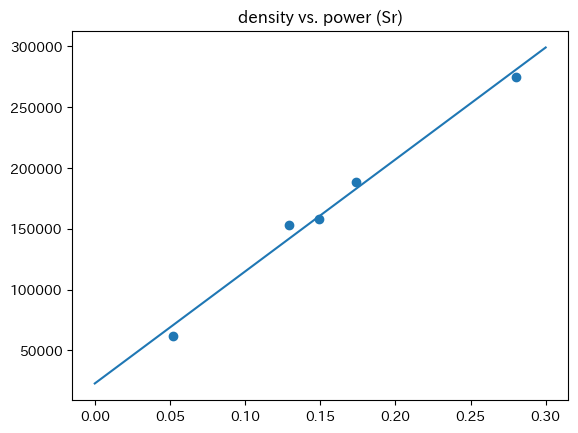

sample47 Sr/Ca ::  8.97160174223473
sample50 Sr/Ca ::  9.17410127525919
24.07210258631589 20.752438110505075


In [2]:
std_density_Ca = np.array([2.715, 6.794, 7.842, 9.151, 14.687])
std_density_Sr = np.array([0.052, 0.129, 0.149, 0.174, 0.280])
std_power_Ca = np.array([56810, 142300, 146400, 174800, 255300])
std_power_Sr = np.array([61480, 153300, 157800, 188300, 274300])
plt.scatter(std_density_Ca, std_power_Ca)
plt.title(r'density vs. power (Ca)')
coef_Ca = np.polyfit(std_density_Ca, std_power_Ca, 1)
a_Ca = coef_Ca[0]
b_Ca = coef_Ca[1]
density = np.linspace(0, 15, 1000)
plt.plot(density, a_Ca * density + b_Ca)
plt.show() 

plt.scatter(std_density_Sr, std_power_Sr)
plt.title(r'density vs. power (Sr)')
coef_Sr = np.polyfit(std_density_Sr, std_power_Sr, 1)
a_Sr = coef_Sr[0]
b_Sr = coef_Sr[1]
density = np.linspace(0, 0.3, 1000)
plt.plot(density, a_Sr * density + b_Sr)
plt.show() 

#以下、計算値
sample_47_Ca_power = 134800
sample_50_Ca_power = 188300
sample_47_Sr_power = 146600
sample_50_Sr_power = 209800
sample_47_Ca_density = (sample_47_Ca_power - b_Ca) / a_Ca
sample_50_Ca_density = (sample_50_Ca_power - b_Ca) / a_Ca
sample_47_Sr_density = (sample_47_Sr_power - b_Ca) / a_Sr
sample_50_Sr_density = (sample_50_Sr_power - b_Ca) / a_Sr

print(r'sample47 Sr/Ca :: ', (sample_47_Sr_density / 87.62) / (sample_47_Ca_density / 40.08) * 10 ** 3)
print(r'sample50 Sr/Ca :: ', (sample_50_Sr_density / 87.62) / (sample_50_Ca_density / 40.08) * 10 ** 3)

sst_47 = (10.44 - (sample_47_Sr_density / 87.62) / (sample_47_Ca_density / 40.08) * 10 ** 3) / 0.061
sst_50 = (10.44 - (sample_50_Sr_density / 87.62) / (sample_50_Ca_density / 40.08) * 10 ** 3) / 0.061
print(sst_47, sst_50)

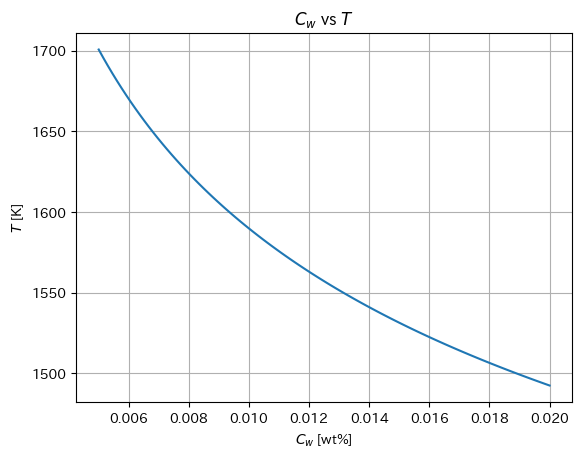

In [ ]:
C = np.linspace(0.005, 0.02, 100)
H = 87 * 10 ** 3
r = 0.62
R = 8.31
sigma_0 = 10 ** 3.1
sigma_ol = 0.1
T = - H / R / np.log(sigma_ol / (sigma_0 * C ** r))
plt.plot(C, T)
plt.xlabel(r"$C_w$ [wt%]")
plt.ylabel(r"$T$ [K]")
plt.title(r"$C_w$ vs $T$")
plt.grid()
plt.show()

In [ ]:
rho = 0.3
mu = 4 * math.pi * 10 ** (-7)
f = 10 ** 9
delta = math.sqrt(rho / (math.pi * mu * f))
print(delta)

0.00871727524698821


In [ ]:
Zxx = complex(-0.784, -0.240)
Zxy = complex(1.36, 1.18)
Zyx = complex(-2.27, -1.46)
Zyy = complex(0.784, 0.240)
theta = - np.array([math.pi / 6])
Zxy_prime = np.abs(- Zxx * np.sin(2 * theta) + Zxy * (np.cos(theta) ** 2) - Zyx * (np.sin(theta) ** 2))
Zyx_prime = np.abs(- Zxx * np.sin(2 * theta) + Zyx * (np.cos(theta) ** 2) - Zxy * (np.sin(theta) ** 2))
theta = theta * (180 / math.pi)
rho_TE = 20 * abs(Zxy_prime) ** 2
rho_TM = 20 * abs(Zyx_prime) ** 2
print(rho_TE, rho_TM)

[38.23045145] [199.18955997]


In [ ]:
v = complex(0.34, 0.589)
theta = cmath.phase(v) * (180 / math.pi)
print(abs(v), theta)

0.6800889647685808 60.00432717901797


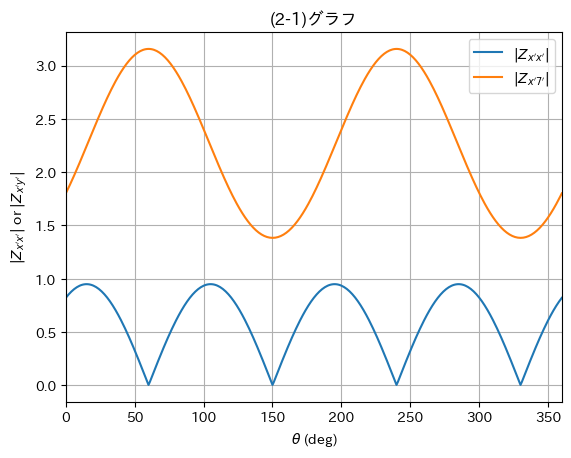

In [ ]:
Zxx = complex(-0.784, -0.240)
Zxy = complex(1.36, 1.18)
Zyx = complex(-2.27, -1.46)
Zyy = complex(0.784, 0.240)
theta = np.linspace(0, 360, 361) * (math.pi / 180)
Zxx_prime = np.abs(Zxx * np.cos(2 * theta) + (Zxy + Zyx) / 2 * np.sin(2 * theta))
Zxy_prime = np.abs(- Zxx * np.sin(2 * theta) + Zxy * (np.cos(theta) ** 2) - Zyx * (np.sin(theta) ** 2))
theta = theta * (180 / math.pi)
plt.plot(theta, Zxx_prime, label=r"$|Z_{x'x'}|$")
plt.plot(theta, Zxy_prime, label=r"$|Z_{x'7'}|$")
plt.grid()
plt.legend()
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$|Z_{x'x'}|$ or $|Z_{x'y'}|$")
plt.title("(2-1)グラフ")
plt.xlim([0, 360])
plt.show()




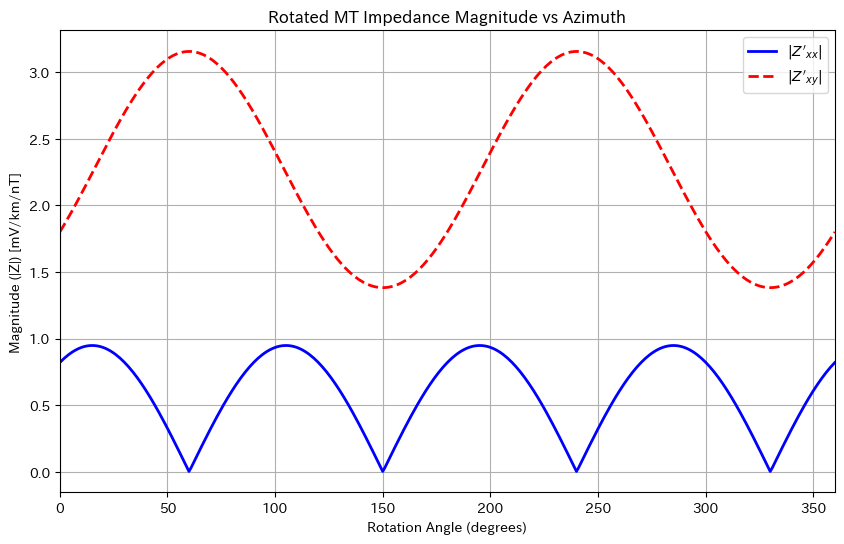

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数の定義 (単位: mV/km/nT 等)
Zxx = complex(-0.784, -0.240)
Zxy = complex(1.36, 1.18)
Zyx = complex(-2.27, -1.46)
Zyy = complex(0.784, 0.240)

# 回転角 theta (0から360度)
theta_deg = np.linspace(0, 360, 361)
theta_rad = np.radians(theta_deg)

# 回転後の値を格納する配列
Zxx_prime_abs = []
Zxy_prime_abs = []

for t in theta_rad:
    cos_t = np.cos(t)
    sin_t = np.sin(t)

    # 回転公式 (基本定義通り)
    # Z' = R Z R^T
    # R = [[cos, sin], [-sin, cos]]

    Zxx_p = Zxx * cos_t**2 + (Zxy + Zyx) * sin_t * cos_t + Zyy * sin_t**2
    Zxy_p = Zxy * cos_t**2 + (Zyy - Zxx) * sin_t * cos_t - Zyx * sin_t**2

    Zxx_prime_abs.append(np.abs(Zxx_p))
    Zxy_prime_abs.append(np.abs(Zxy_p))

# グラフの描画
plt.figure(figsize=(10, 6))
plt.plot(theta_deg, Zxx_prime_abs, label=r"$|Z'_{xx}|$", color='blue', linewidth=2)
plt.plot(theta_deg, Zxy_prime_abs, label=r"$|Z'_{xy}|$", color='red', linewidth=2, linestyle='--')

plt.title("Rotated MT Impedance Magnitude vs Azimuth")
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Magnitude (|Z|) [mV/km/nT]")
plt.xlim(0, 360)
plt.grid(True)
plt.legend()
plt.show()

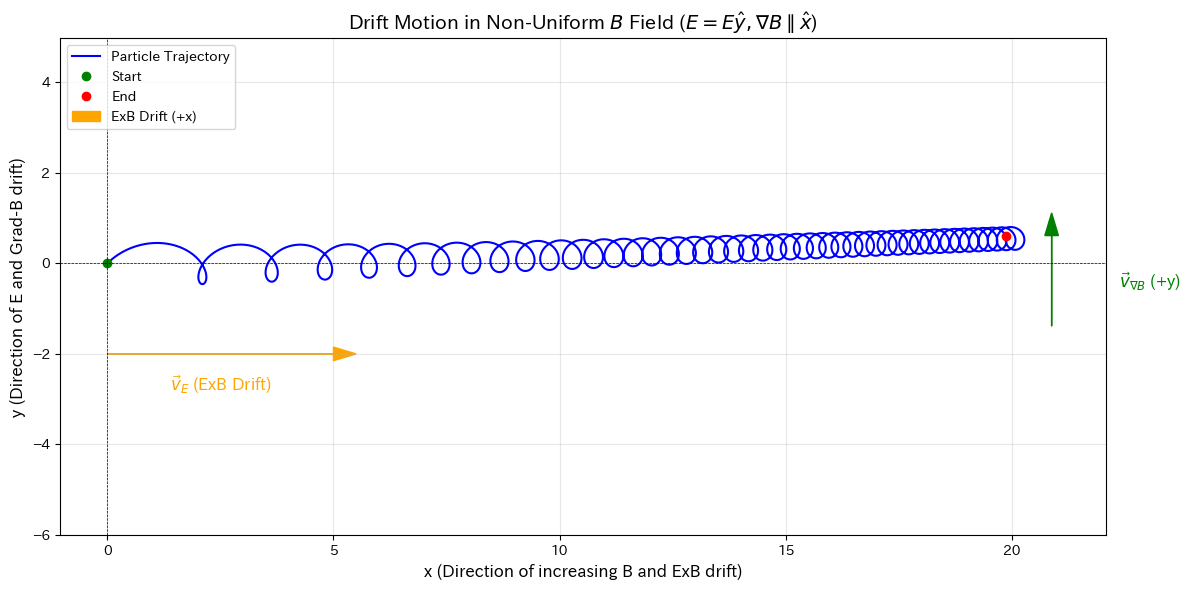

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def plot_drift_motion():
    # --- 物理定数とパラメータ ---
    q = 1.0       # 電荷
    m = 1.0       # 質量
    E0 = 0.5      # 電場の強さ (y方向)
    B0 = 1.0      # 基準磁場
    alpha = 0.15  # 磁場の勾配係数 (B(x) = B0 * (1 + alpha * x))

    # 磁場関数 B(x) = B0(1 + alpha*x)
    # xが増えるほど磁場が強くなる設定
    def get_B(x):
        return B0 * (1.0 + alpha * x)

    # --- 運動方程式 ---
    # 状態ベクトル S = [x, y, vx, vy]
    # dS/dt = [vx, vy, ax, ay]
    def equations(t, S):
        x, y, vx, vy = S

        Bx = 0.0
        By = 0.0
        Bz = get_B(x)

        Ex = 0.0
        Ey = E0

        # Lorentz力: F = q(E + v x B)
        # ax = (q/m) * (Ex + vy*Bz - vz*By)  (vz=0と仮定)
        # ay = (q/m) * (Ey + vz*Bx - vx*Bz)

        ax = (q / m) * (Ex + vy * Bz)
        ay = (q / m) * (Ey - vx * Bz)

        return [vx, vy, ax, ay]

    # --- シミュレーション設定 ---
    t_span = (0, 100)           # 時間範囲
    t_eval = np.linspace(0, 100, 2000) # 評価点

    # 初期条件: [x0, y0, vx0, vy0]
    # サイクロトロン運動が見えやすいよう、少し初速度を持たせる
    initial_state = [0.0, 0.0, 0.5, 0.5]

    # --- 積分実行 (Runge-Kutta法) ---
    sol = solve_ivp(equations, t_span, initial_state, t_eval=t_eval, rtol=1e-9, atol=1e-9)

    x = sol.y[0]
    y = sol.y[1]

    # --- プロット ---
    plt.figure(figsize=(12, 6))

    # 軌跡のプロット
    plt.plot(x, y, label='Particle Trajectory', color='blue', linewidth=1.5)

    # 開始点と終了点
    plt.plot(x[0], y[0], 'go', label='Start')
    plt.plot(x[-1], y[-1], 'ro', label='End')

    # 解説用矢印とテキスト
    # ExBドリフト方向
    plt.arrow(0, -2, 5, 0, head_width=0.3, head_length=0.5, fc='orange', ec='orange', label='ExB Drift (+x)')
    plt.text(2.5, -2.8, r'$\vec{v}_E$ (ExB Drift)', color='orange', ha='center', fontsize=12)

    # Grad-Bドリフト方向
    plt.arrow(x[-1]+1, y[-1]-2, 0, 2, head_width=0.3, head_length=0.5, fc='green', ec='green')
    plt.text(x[-1]+2.5, y[-1]-1, r'$\vec{v}_{\nabla B}$ (+y)', color='green', va='center', fontsize=12)

    # 装飾
    plt.title(r'Drift Motion in Non-Uniform $B$ Field ($E=E\hat{y}, \nabla B \parallel \hat{x}$)', fontsize=14)
    plt.xlabel('x (Direction of increasing B and ExB drift)', fontsize=12)
    plt.ylabel('y (Direction of E and Grad-B drift)', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    plt.axis('equal') # アスペクト比を1:1にして円運動の歪みを防ぐ

    # グラフの表示
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_drift_motion()

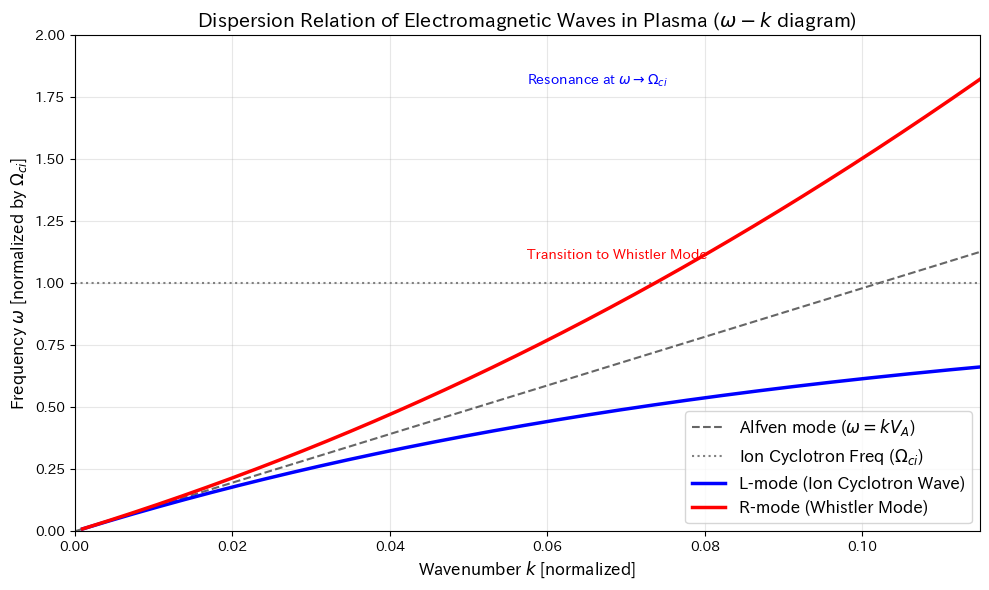

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dispersion_relation():
    # --- パラメータ設定 (視覚化のための正規化単位) ---
    # Ωci (イオンサイクロトロン周波数) を 1.0 として正規化
    Om_ci = 1.0

    # 質量比 (mi/me).
    # 実際は1836程度ですが、グラフの特性を見やすくするためにあえて小さく(25)設定します。
    # これにより、RモードとLモードの違いが明確に図示されます。
    mass_ratio = 25.0

    # Ωce (電子サイクロトロン周波数). 定義より負の値.
    Om_ce = -1.0 * mass_ratio * Om_ci

    # プラズマ周波数 (ωpi). アルベン速度を定義するために設定.
    # 通常 ωpi >> Ωci なので大きめの値を設定
    w_pi = 100.0
    w_pe = w_pi * np.sqrt(mass_ratio)

    # 光速 c (アルベン速度に対して十分に大きい値)
    c = 1000.0

    # --- アルベン速度 VA の計算 ---
    # 低周波極限の係数から逆算: VA = c / sqrt(wp_term)
    # 右辺の係数 = (w_pe^2 / Om_ce^2) + (w_pi^2 / Om_ci^2)
    rho_term = (w_pe**2 / Om_ce**2) + (w_pi**2 / Om_ci**2)
    V_A = c / np.sqrt(rho_term)

    # --- 分散関係の計算関数 ---
    # 式(1)を変形して k を求める関数: k = (w/c) * sqrt(RHS)
    def calculate_k(w):
        # 式(1)の右辺のカッコ内
        # - w_pe^2 / (w * (w + Om_ce)) - w_pi^2 / (w * (w + Om_ci))
        term_e = - (w_pe**2) / (w * (w + Om_ce))
        term_i = - (w_pi**2) / (w * (w + Om_ci))
        rhs = term_e + term_i

        # k^2 c^2 / w^2 = rhs  =>  k = (w/c) * sqrt(rhs)
        # rhsが負の場合は波動が存在できない(evanescent)ためNaNを返す
        k_sq = (w**2 / c**2) * rhs

        # 配列操作のために np.where を使用
        k_values = np.sqrt(np.where(k_sq >= 0, k_sq, np.nan))
        return k_values

    # --- データの生成 ---
    # Lモード (左円偏波): ω < 0
    # 範囲: 共鳴点(-Ωci)の直前から0付近まで
    w_L_range = np.linspace(-Om_ci + 0.01, -0.01, 1000)
    k_L = calculate_k(w_L_range)

    # Rモード (右円偏波): ω > 0
    # 範囲: 0付近から、Ωciを超えてさらに高い周波数まで
    w_R_range = np.linspace(0.01, 2.5 * Om_ci, 1000)
    k_R = calculate_k(w_R_range)

    # --- プロットの作成 ---
    plt.figure(figsize=(10, 6))

    # 1. アルベン波の直線 (ω = k * VA)
    # kの範囲に合わせて線を描画
    k_max = np.nanmax(k_R)
    plt.plot([0, k_max], [0, k_max * V_A], 'k--', linewidth=1.5, alpha=0.6, label=r'Alfven mode ($\omega = k V_A$)')

    # 2. 共鳴周波数 Ωci のライン
    plt.axhline(y=Om_ci, color='gray', linestyle=':', label=r'Ion Cyclotron Freq ($\Omega_{ci}$)')

    # 3. Lモード (絶対値をとって表示)
    # 問題文でω<0がLモードとされているが、分散曲線図は通常第1象限(|ω|-k)に描くため
    plt.plot(k_L, np.abs(w_L_range), 'b-', linewidth=2.5, label='L-mode (Ion Cyclotron Wave)')

    # 4. Rモード
    plt.plot(k_R, w_R_range, 'r-', linewidth=2.5, label='R-mode (Whistler Mode)')

    # --- グラフの装飾 ---
    plt.title(r'Dispersion Relation of Electromagnetic Waves in Plasma ($\omega-k$ diagram)', fontsize=14)
    plt.xlabel(r'Wavenumber $k$ [normalized]', fontsize=12)
    plt.ylabel(r'Frequency $\omega$ [normalized by $\Omega_{ci}$]', fontsize=12)
    plt.xlim(0, np.nanmax(k_R)*0.8)
    plt.ylim(0, 2.0) # Ωci の2倍程度まで表示

    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, alpha=0.3)

    # テキスト注釈
    plt.text(0.5, 0.9, r'Resonance at $\omega \to \Omega_{ci}$', color='blue', transform=plt.gca().transAxes)
    plt.text(0.5, 0.55, r'Transition to Whistler Mode', color='red', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_dispersion_relation()

In [ ]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("berkeleyearth/climate-change-earth-surface-temperature-data")

print("Path to dataset files:", path)

   ---------------------------------------- 0.0/69.2 kB ? eta -:--:--
   ----------------------------------- ---- 61.4/69.2 kB 1.6 MB/s eta 0:00:01
   ----------------------------------- ---- 61.4/69.2 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 69.2/69.2 kB 627.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/160.0 kB ? eta -:--:--
   ---------------------------------------- 160.0/160.0 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/437.0 kB ? eta -:--:--
   ---------------------------------------  430.1/437.0 kB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 437.0/437.0 kB 6.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\y\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


100%|██████████| 84.7M/84.7M [00:10<00:00, 8.51MB/s]

Extracting files...


Path to dataset files: C:\Users\y\.cache\kagglehub\datasets\berkeleyearth\climate-change-earth-surface-temperature-data\versions\2


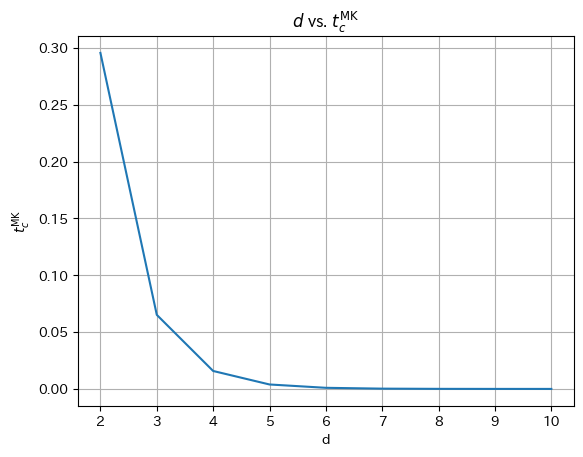

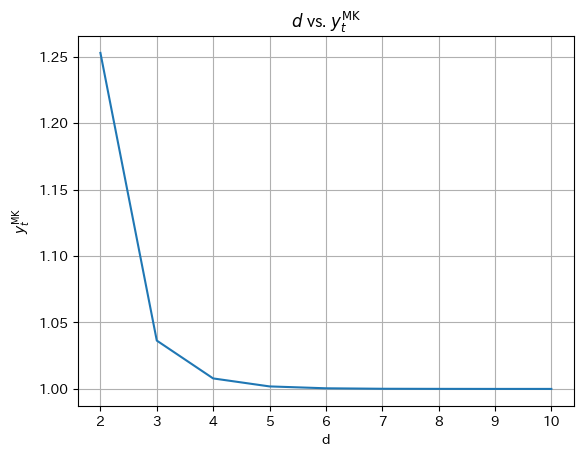

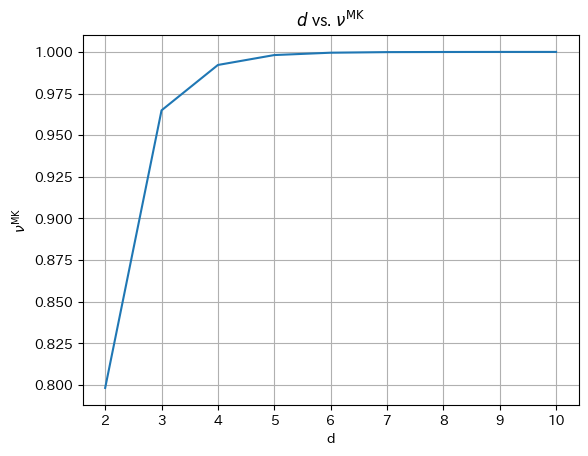

In [ ]:
d = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])
t = np.array([0.295598, 0.065174, 0.015789, 0.0039164, 0.0009772, 0.00024418, 0.000061038, 0.0000152589, 0.0000038147])
plt.plot(d, t)
plt.xlabel(r'd')
plt.ylabel(r'$t_c^{\text{MK}}$')
plt.grid()
plt.title(r'$d$ vs. $t_c^{\text{MK}}$')
plt.show()

lamda = np.tanh(2 ** (d - 2) * np.log((1 + t) / (1 - t))) * (2 ** d) / (1 - t ** 2)
y = np.log(lamda) / np.log(2)
nu = 1 / y
plt.plot(d, y)
plt.xlabel(r'd')
plt.ylabel(r'$y_t^{\text{MK}}$')
plt.grid()
plt.title(r'$d$ vs. $y_t^{\text{MK}}$')
plt.show()

plt.plot(d, nu)
plt.xlabel(r'd')
plt.ylabel(r'$\nu^{\text{MK}}$')
plt.grid()
plt.title(r'$d$ vs. $\nu^{\text{MK}}$')
plt.show()

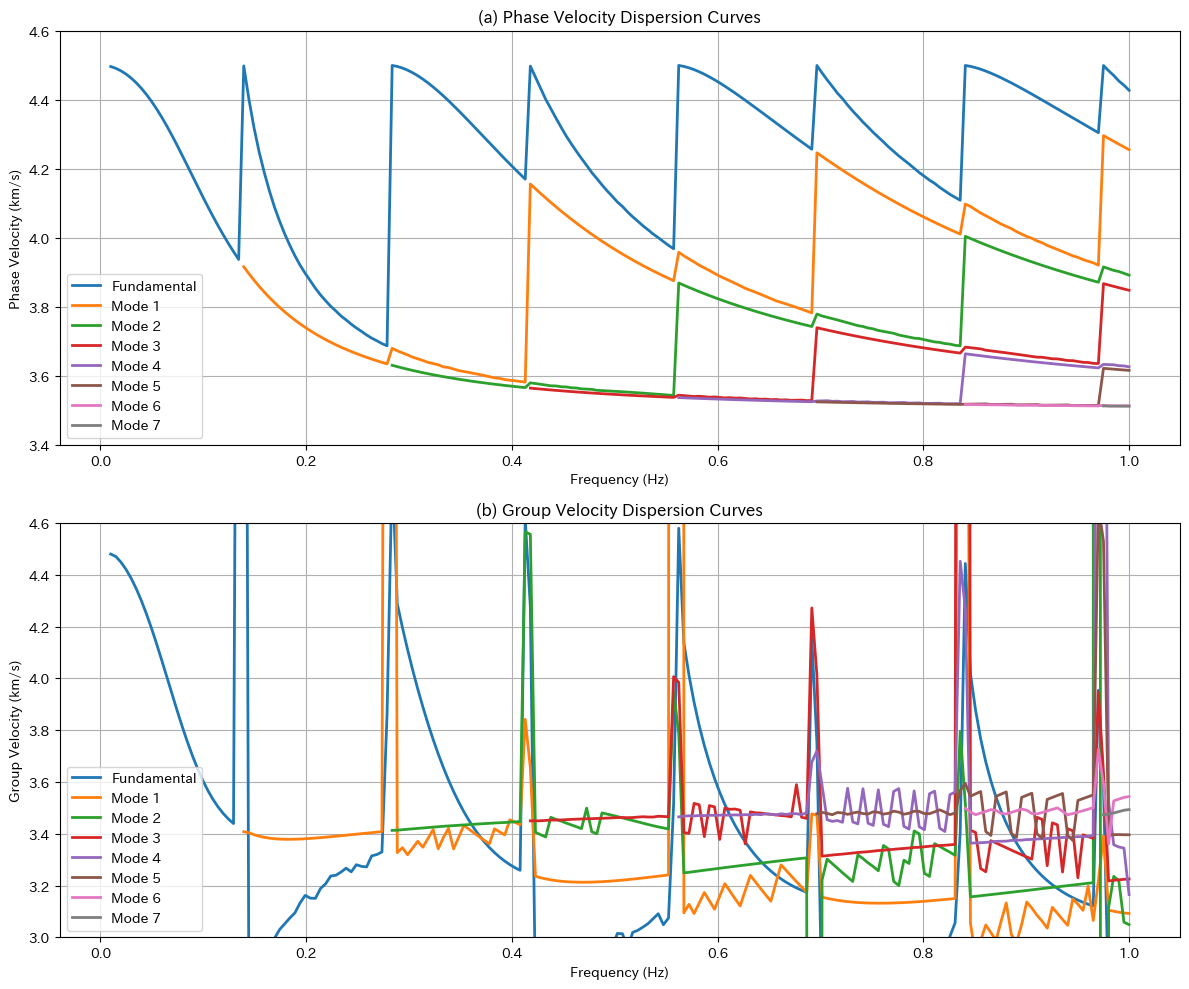

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- パラメータ設定 ---
beta1 = 3.5  # 上層 S波速度 (km/s)
rho1 = 2.5   # 上層 密度 (g/cm^3 or 10^3 kg/m^3)
H = 10.0     # 上層 厚さ (km)

beta2 = 4.5  # 下層 S波速度 (km/s)
rho2 = 3.2   # 下層 密度

# 剛性率 mu = rho * beta^2
mu1 = rho1 * beta1**2
mu2 = rho2 * beta2**2

# --- 分散方程式の定義 ---
def dispersion_eq(c, omega):
    """
    Love波の分散方程式の残差を返す関数
    tan(k_z1 * H) - (mu2 * k_z2) / (mu1 * k_z1) = 0
    """
    # cが範囲外の場合は計算不可
    if c <= beta1 or c >= beta2:
        return None

    # 鉛直波数
    # k_z1 = omega * sqrt(1/beta1^2 - 1/c^2)
    kz1 = omega * np.sqrt(1/beta1**2 - 1/c**2)
    # k_z2 = omega * sqrt(1/c^2 - 1/beta2^2)
    kz2 = omega * np.sqrt(1/c**2 - 1/beta2**2)

    lhs = np.tan(kz1 * H)
    rhs = (mu2 * kz2) / (mu1 * kz1)

    return lhs - rhs

# --- 計算ループ ---
freqs = np.linspace(0.01, 1.0, 200) # 0.01Hzから1Hzまで
c_scan = np.linspace(beta1 + 0.0001, beta2 - 0.0001, 1000) # cの探索範囲

modes_data = [] # 結果格納用

for f in freqs:
    omega = 2 * np.pi * f

    # cをスキャンして解を探す（符号が変わる場所を探す）
    residuals = [dispersion_eq(c, omega) for c in c_scan]

    # 符号が変わる点を検出（＝解）
    roots = []
    for i in range(len(residuals) - 1):
        if residuals[i] is not None and residuals[i+1] is not None:
            if residuals[i] * residuals[i+1] < 0:
                # 線形補間でより正確なcを求める
                c_approx = c_scan[i] + (c_scan[i+1]-c_scan[i]) * \
                           (0 - residuals[i]) / (residuals[i+1] - residuals[i])
                roots.append(c_approx)

    # 高次モード順にソート（速度が大きいほうが低次モード）
    roots.sort(reverse=True)

    for mode_idx, c_val in enumerate(roots):
        modes_data.append({
            'mode': mode_idx, # 0:基本, 1:第一高次...
            'freq': f,
            'omega': omega,
            'c': c_val,
            'k': omega / c_val
        })

# --- データの整理と群速度計算 ---
# モードごとにデータを分ける
unique_modes = sorted(list(set([d['mode'] for d in modes_data])))

plt.figure(figsize=(12, 10))

# (a) 位相速度のプロット
plt.subplot(2, 1, 1)
for m in unique_modes:
    # 特定のモードのデータを抽出
    data_m = [d for d in modes_data if d['mode'] == m]
    fs = np.array([d['freq'] for d in data_m])
    cs = np.array([d['c'] for d in data_m])

    label_name = "Fundamental" if m == 0 else f"Mode {m}"
    plt.plot(fs, cs, label=label_name, linewidth=2)

plt.ylabel('Phase Velocity (km/s)')
plt.xlabel('Frequency (Hz)')
plt.title('(a) Phase Velocity Dispersion Curves')
plt.grid(True)
plt.ylim(3.4, 4.6)
plt.legend()

# (b) 群速度のプロット
plt.subplot(2, 1, 2)
for m in unique_modes:
    data_m = [d for d in modes_data if d['mode'] == m]
    if len(data_m) < 2: continue

    fs = np.array([d['freq'] for d in data_m])
    ws = np.array([d['omega'] for d in data_m])
    ks = np.array([d['k'] for d in data_m])

    # 群速度 U = d(omega) / dk
    # 数値微分で計算
    # データの密度が十分あるので差分近似を使用
    dU = np.gradient(ws, ks)

    label_name = "Fundamental" if m == 0 else f"Mode {m}"
    plt.plot(fs, dU, label=label_name, linewidth=2)

plt.ylabel('Group Velocity (km/s)')
plt.xlabel('Frequency (Hz)')
plt.title('(b) Group Velocity Dispersion Curves')
plt.grid(True)
plt.ylim(3.0, 4.6) # 群速度はエアリーフェーズで極小値をとる
plt.legend()

plt.tight_layout()
plt.show()

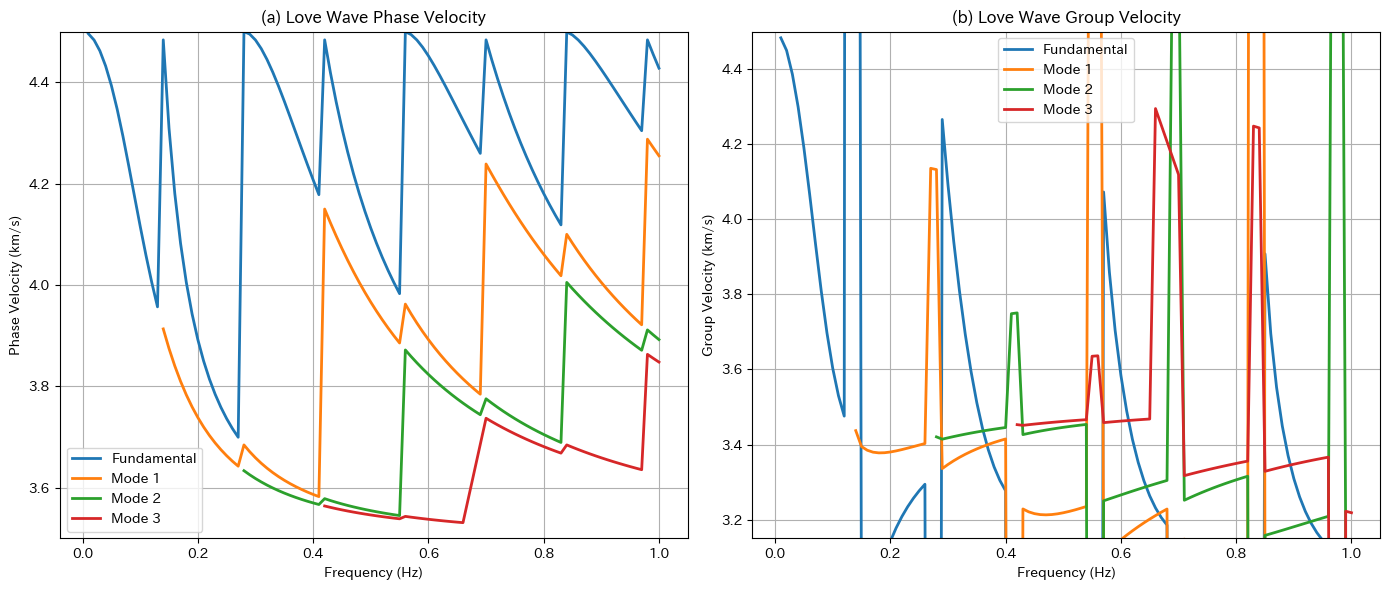

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- パラメータ ---
beta1 = 3.5  # km/s
beta2 = 4.5  # km/s
rho1 = 2.5   # g/cm^3 (比率計算のため単位系は揃っていればOK)
rho2 = 3.2   # g/cm^3
H = 10.0     # km

mu1 = rho1 * beta1**2
mu2 = rho2 * beta2**2

# --- 分散方程式 (Characteristic Equation) ---
# c: 位相速度, w: 角周波数
def love_dispersion(c, w):
    if c <= beta1 or c >= beta2:
        return None

    k = w / c
    # 上層の垂直波数成分
    r1 = np.sqrt((c/beta1)**2 - 1)
    # 下層の垂直波数成分
    r2 = np.sqrt(1 - (c/beta2)**2)

    lhs = np.tan(k * H * np.sqrt((1/beta1)**2 - (1/c)**2) * c) # = tan(w*H * sqrt(...))
    # 簡易化: tan(k * H * r1) = (mu2 * r2) / (mu1 * r1)
    # k * H * r1 = w/c * H * sqrt(c^2/b1^2 - 1) = w*H * sqrt(1/b1^2 - 1/c^2)

    # 厳密な方程式変形
    # tan(omega * H * sqrt(1/beta1^2 - 1/c^2)) - ... = 0
    term1 = w * H * np.sqrt(1/beta1**2 - 1/c**2)
    term2 = (mu2 * np.sqrt(1/c**2 - 1/beta2**2)) / (mu1 * np.sqrt(1/beta1**2 - 1/c**2))

    return np.tan(term1) - term2

# --- 計算ループ ---
freqs = np.linspace(0.01, 1.0, 100) # 0.01Hz ～ 1Hz
phase_velocities = {0: [], 1: [], 2: [], 3: []} # モードごとの位相速度格納用
group_velocities = {0: [], 1: [], 2: [], 3: []} # 群速度格納用
valid_freqs = {0: [], 1: [], 2: [], 3: []}

for f in freqs:
    w = 2 * np.pi * f

    # cの探索範囲 (beta1 < c < beta2)
    # タンジェントの周期性により複数の解（モード）が存在する
    # 数値計算のため、探索グリッドを作成して根を探す
    c_search = np.linspace(beta1 + 0.0001, beta2 - 0.0001, 200)
    signs = np.sign([love_dispersion(c, w) for c in c_search])

    roots = []
    for i in range(len(signs)-1):
        if signs[i] * signs[i+1] < 0:
            # 符号が変わる区間で解を探す
            try:
                root = brentq(love_dispersion, c_search[i], c_search[i+1], args=(w,))
                roots.append(root)
            except:
                pass

    # 根をソート（大きい順：基本モードが最も速度が速い...とは限らず、通常は高次ほどカットオフ周波数が高い）
    # Love波の場合、同じ周波数では高次モードほど位相速度は速い（カットオフ付近）が、
    # 物理的には分散曲線のブランチとして整理する必要がある。
    # ここでは単純に検出された根を逆順（基本モードが右側、高次が左側に出る一般的な図に合わせて整理）にする。
    # 通常、cが大きい順に 基本(n=0), 第1高次(n=1)... となるが、高次は低周波で存在しない。

    roots.sort(reverse=True) # 大きい順にソート (cに近い方が基本モード)

    for mode_idx, c_val in enumerate(roots):
        if mode_idx in phase_velocities:
            phase_velocities[mode_idx].append(c_val)
            valid_freqs[mode_idx].append(f)

# --- 群速度の計算 (U = c + k * dc/dk -> U = c / (1 - (f/c)*(dc/df))) ---
# 数値微分を用いて計算
for m in phase_velocities:
    cs = np.array(phase_velocities[m])
    fs = np.array(valid_freqs[m])
    if len(cs) > 1:
        # dc/df を計算
        dcdf = np.gradient(cs, fs)
        # U = c / (1 - (f/c) * (dc/df))
        Us = cs / (1 - (fs/cs) * dcdf)
        group_velocities[m] = Us

# --- プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# (a) 位相速度
for m in phase_velocities:
    if len(valid_freqs[m]) > 0:
        label = "Fundamental" if m == 0 else f"Mode {m}"
        ax1.plot(valid_freqs[m], phase_velocities[m], label=label, linewidth=2)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Phase Velocity (km/s)')
ax1.set_title('(a) Love Wave Phase Velocity')
ax1.set_ylim(beta1, beta2)
ax1.grid(True)
ax1.legend()

# (b) 群速度
for m in group_velocities:
    if len(valid_freqs[m]) > 0:
        label = "Fundamental" if m == 0 else f"Mode {m}"
        ax2.plot(valid_freqs[m], group_velocities[m], label=label, linewidth=2)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Group Velocity (km/s)')
ax2.set_title('(b) Love Wave Group Velocity')
ax2.set_ylim(beta1*0.9, beta2) # 群速度はAiry Phaseでbeta1より遅くなることがあるため少し広げる
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import math
Q = math.log(100) / math.pi / (3.5 / 3.48 - 1)
print(Q)

255.06158841003872


In [ ]:
import math
R2 = (10.01 + 0.0) * 10 ** (3)
R3 = (9.98 + 0.0) * 10 ** (3)
C1 = (4.7 + 0.0) * 10 ** (-9)
C4 = (32.73 + 0.0) * 10 ** (-9)
omega_c = 1 / math.sqrt(R2 * R3 * C1 * C4)
f_c = omega_c / (2 * math.pi)
Q = 1 / (omega_c * C1 * (R2 + R3))
print(f_c)
print(Q)

1283.8547452716593
1.3194519793210213


In [ ]:
import math
R2 = (10.01 + 0.0) * 10 ** (3)
R3 = (9.98 + 0.0) * 10 ** (3)
C1 = (4.7 + 0.0) * 10 ** (-9)
C4 = (32.73 + 0.0) * 10 ** (-9)
omega_c = 1 / math.sqrt(R2 * R3 * C1 * C4)
f_c = omega_c / (2 * math.pi)
Q = 1 / (omega_c * C1 * (R2 + R3))
print(f_c)
print(Q)

1283.8547452716593
False


In [ ]:
import numpy as np
import math
R = np.array([10.01 + 0.05, 9.98 + 0.05, 9.98 - 0.05, 10.01 - 0.05, 3.3, 4.7, 10, 22, 33, 47, 100, 220, 330, 470, 1000]) * 10 ** 3
C = np.array([0.0047 + 0.00019, 0.0047 - 0.00019, 0.03273 + 0.00012, 0.03273 - 0.00012, 0.001, 0.0022, 0.0033, 0.0047, 0.01, 0.022, 0.033, 0.047, 0.1, 0.22, 0.33, 0.47, 1, 2.2]) * 10 ** (-6)
count = 0
Q_calc = []
for i in range(len(R)):
    for j in range(len(R)):
        for k in range(len(C)):
            for l in range(len(C)):
                R2 = R[i]
                R3 = R[j]
                C1 = C[k]
                C4 = C[l]
                omega_c = 1 / math.sqrt(R2 * R3 * C1 * C4)
                f_c = omega_c / (2 * math.pi)
                Q = 1 / (omega_c * C1 * (R2 + R3))
                if Q < 0.2 and Q > 0.18:
                    if f_c > 500 and f_c < 2000 and R2 < 10170 and R2 > 9950 and R3 < 10300 and R3 > 9930 and C1 > 32 * 10 ** (-9) and C1 < 33 * 10 ** (-9) and C4 > 4 * 10 ** (-9) and C4 < 5 * 10 ** (-9):
                        print("R2, R3, C1, C4, Q, fc::", R2, R3, C1, C4, Q, f_c)
                        Q_calc.append(Q)
                        count = count + 1
print("比率 :", count / (len(R)**2 * len(C) ** 2))
Q_calc = np.array(Q_calc)
print(Q_calc.min(), Q_calc.max())


R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.285e-08 4.89e-09 0.19291089101485723 1248.2455728319826
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.285e-08 4.5099999999999995e-09 0.18526380877879733 1299.7690549905567
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.285e-08 4.7e-09 0.18912600391719392 1273.2261067906848
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.261e-08 4.89e-09 0.19361947334909682 1252.8305123190607
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.261e-08 4.5099999999999995e-09 0.1859443025621394 1304.543245737966
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.261e-08 4.7e-09 0.18982068395633553 1277.9028024506256
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.3e-08 4.89e-09 0.19247195781581938 1245.405419953181
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.3e-08 4.5099999999999995e-09 0.1848422751068236 1296.8116699185366
R2, R3, C1, C4, Q, fc:: 10060.0 10060.0 3.3e-08 4.7e-09 0.18869568253158475 1270.3291153081814
R2, R3, C1, C4, Q, fc:: 10060.0 10030.000000000002 3.285e-08 4.89e-09 0.19291067593010217

In [ ]:
atmo_energy = np.array([79, 85, 20, 397, -239, -342])
#エネルギー収支(太陽放射による、地上からの潜熱、地上からの顕熱、地上からの熱流、宇宙への熱流、地上への熱流)
print(atmo_energy.sum())

0


C:\Users\y\AppData\Local\Temp\ipykernel_8936\788083831.py:15: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y = sph_harm(m, l, phi, theta)


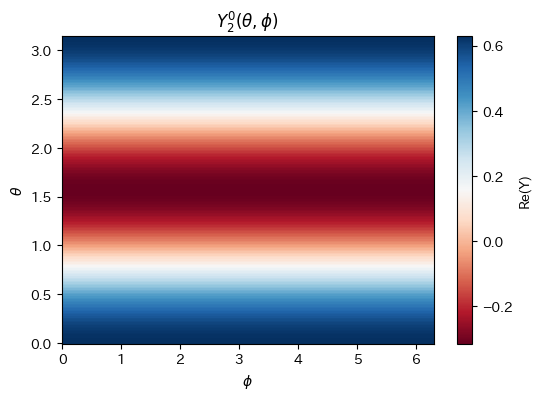

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

# パラメータ
l = 2
m = 0

# グリッド
theta = np.linspace(0, np.pi, 200)
phi = np.linspace(0, 2*np.pi, 200)
theta, phi = np.meshgrid(theta, phi)

# 球面調和関数
Y = sph_harm(m, l, phi, theta)

# 実部をプロット（absやimagでもOK）
plt.figure(figsize=(6, 4))
plt.pcolormesh(phi, theta, np.real(Y), shading='auto', cmap='RdBu')
plt.colorbar(label='Re(Y)')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.title(rf'$Y_{{{l}}}^{{{m}}}(\theta,\phi)$')
plt.show()


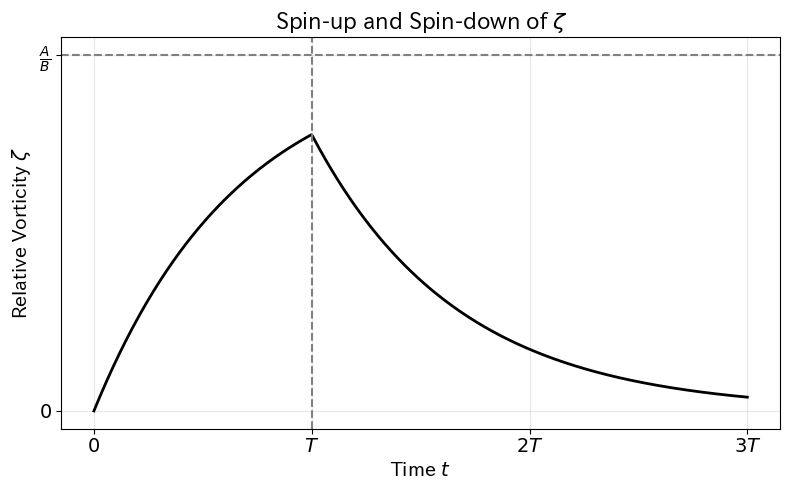

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. パラメータ設定 (適当な値を設定して概形を描く)
A = 1.0       # 強制項の強さ
B = 0.5       # 減衰係数 (1/tau_decay)
t = 3
T = t     # 風が止む時間
t_max = 3 * t  # 描画する最大の時間

# 時間軸の作成
t = np.linspace(0, t_max, 500)

# 2. 渦度 zeta の計算
zeta = np.zeros_like(t)

# A/B (定常解の漸近値)
zeta_steady = A / B

for i, time in enumerate(t):
    if time <= T:
        # Spin-up (0 <= t <= T)
        zeta[i] = (A / B) * (1 - np.exp(-B * time))
    else:
        # Spin-down (t > T)
        # t=T の瞬間の値 (zeta_max) から減衰
        zeta_max = (A / B) * (1 - np.exp(-B * T))
        zeta[i] = zeta_max * np.exp(-B * (time - T))

# 3. プロット
plt.figure(figsize=(8, 5))
plt.plot(t, zeta, 'k-', linewidth=2, label=r'$\zeta(t)$') # k-は黒の実線

# 補助線 (点線)
plt.axvline(x=T, color='gray', linestyle='--')       # t=T の縦線
plt.axhline(y=zeta_steady, color='gray', linestyle='--') # 漸近線 (A/B)

# --- ここが質問の回答部分 ---
# X軸の目盛りを T, 2T などに変更
# plt.xticks([数値の位置リスト], [表示文字リスト])
plt.xticks([0, T, 2*T, 3*T], [r'$0$', r'$T$', r'$2T$', r'$3T$'], fontsize=14)

# Y軸の目盛りも数式に変更 (0 と A/B)
plt.yticks([0, zeta_steady], [r'$0$', r'$\frac{A}{B}$'], fontsize=14)
# ------------------------

# ラベルなど
plt.xlabel(r'Time $t$', fontsize=14)
plt.ylabel(r'Relative Vorticity $\zeta$', fontsize=14)
plt.title(r'Spin-up and Spin-down of $\zeta$', fontsize=16)

# グリッドや微調整
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 表示
plt.show()

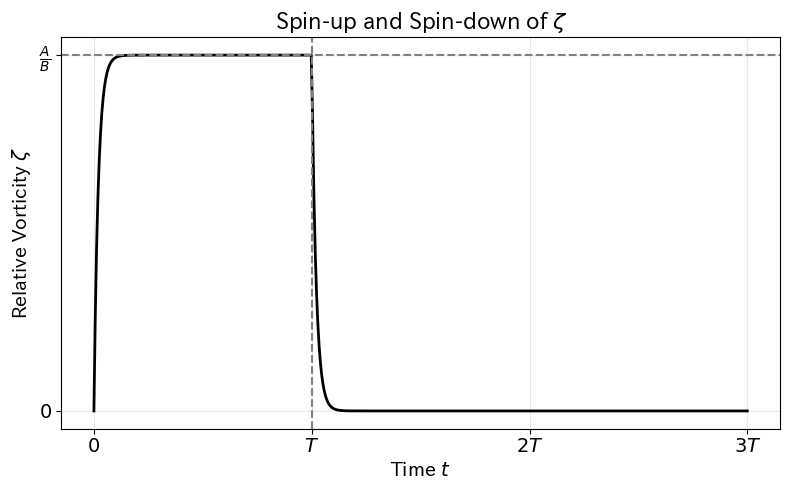

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. パラメータ設定 (適当な値を設定して概形を描く)
A = 1.0       # 強制項の強さ
B = 0.5       # 減衰係数 (1/tau_decay)
t = 100
T = t     # 風が止む時間
t_max = 3 * t  # 描画する最大の時間

# 時間軸の作成
t = np.linspace(0, t_max, 500)

# 2. 渦度 zeta の計算
zeta = np.zeros_like(t)

# A/B (定常解の漸近値)
zeta_steady = A / B

for i, time in enumerate(t):
    if time <= T:
        # Spin-up (0 <= t <= T)
        zeta[i] = (A / B) * (1 - np.exp(-B * time))
    else:
        # Spin-down (t > T)
        # t=T の瞬間の値 (zeta_max) から減衰
        zeta_max = (A / B) * (1 - np.exp(-B * T))
        zeta[i] = zeta_max * np.exp(-B * (time - T))

# 3. プロット
plt.figure(figsize=(8, 5))
plt.plot(t, zeta, 'k-', linewidth=2, label=r'$\zeta(t)$') # k-は黒の実線

# 補助線 (点線)
plt.axvline(x=T, color='gray', linestyle='--')       # t=T の縦線
plt.axhline(y=zeta_steady, color='gray', linestyle='--') # 漸近線 (A/B)

# --- ここが質問の回答部分 ---
# X軸の目盛りを T, 2T などに変更
# plt.xticks([数値の位置リスト], [表示文字リスト])
plt.xticks([0, T, 2*T, 3*T], [r'$0$', r'$T$', r'$2T$', r'$3T$'], fontsize=14)

# Y軸の目盛りも数式に変更 (0 と A/B)
plt.yticks([0, zeta_steady], [r'$0$', r'$\frac{A}{B}$'], fontsize=14)
# ------------------------

# ラベルなど
plt.xlabel(r'Time $t$', fontsize=14)
plt.ylabel(r'Relative Vorticity $\zeta$', fontsize=14)
plt.title(r'Spin-up and Spin-down of $\zeta$', fontsize=16)

# グリッドや微調整
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 表示
plt.show()

In [ ]:
xi = 0.83682
r_a = math.sqrt(1 - xi / 2.8)
r_b = math.sqrt(1 - xi)
ratio = (-r_a + (1 + r_b ** 2) / (2 * r_b)) / (1 - (1 + r_b ** 2) / 2)
print("r :", ratio)
T = 1
beta = 3500
k_x = 2 * math.pi / (T * beta * math.sqrt(xi))
z = math.log((1 + r_b ** 2) / 2) / (k_x * (r_b - r_a))
print("z ::", z)

r : 1.4397350091509546
z :: 637.2696168562034


In [ ]:
omega_kougisiryou = 0.27 #[deg/year]
omega_kougisiryou = omega_kougisiryou * math.pi / 180 / (365 * 24 * 3600) #[rad/s]
L_kougisiryou = 3500 #[km] 外核の半径くらい
L_kougisiryou = L_kougisiryou * 1000 #[m]
U_kougisiryou = L_kougisiryou * omega_kougisiryou
mu_0 = 1.256637 * 10 ** (-6)
sigma = 6 * 10 ** 5
sigma_up = 10 ** 6
sigma_low = 2 * 10 ** 5
eta = 1 / (sigma * mu_0)
eta_up = 1 / (sigma_low * mu_0)
eta_low = 1 / (sigma_up * mu_0)
delta = (eta_up - eta_low) / 2
print("eta ::", eta, "±", delta)
reynolds_number = U_kougisiryou * L_kougisiryou / eta
reynolds_number_low = U_kougisiryou * L_kougisiryou / eta_up
reynolds_number_up = U_kougisiryou * L_kougisiryou / eta_low
delta = (reynolds_number_up - reynolds_number_low) / 2
print("U_講義資料 [m/s]", U_kougisiryou)
print("Reynolds number ::", reynolds_number, "±",delta)

eta :: 1.3262912572737129 ± 1.5915495087284555
U_講義資料 [m/s] 0.0005230010601010406
Reynolds number :: 1380.167214640602 ± 920.1114764270678


C:\Users\y\AppData\Local\Temp\ipykernel_8936\1404045857.py:4: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


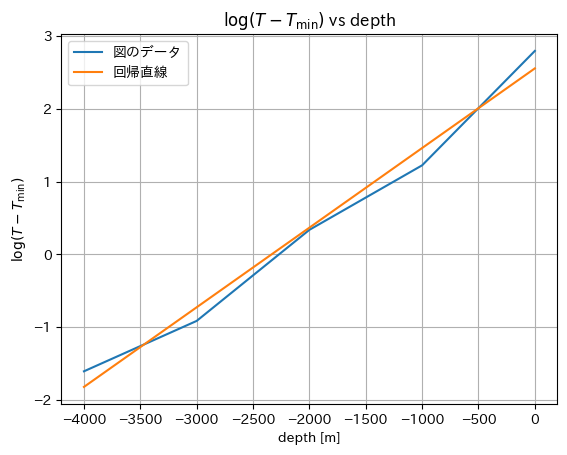

a :: 0.001095350465802494
K_v :: 9.129498103306718e-05


In [ ]:
depth = np.array([0, -1000, -2000, -3000, -4000, -5000])
T = np.array([18, 5, 3, 2, 1.8, 1.6]) + 273.15
T = T - T[-1]
log_T = np.log(T)
a, b = np.polyfit(depth[:-1], log_T[:-1], 1)

plt.plot(depth[:-1], log_T[:-1], label="図のデータ")
plt.plot(depth[:-1], a * depth[:-1] + b, label="回帰直線")
plt.xlabel("depth [m]")
plt.ylabel(r'$\log(T-T_{\text{min}})$')
plt.grid()
plt.legend()
plt.title(r'$\log(T-T_{\text{min}})$ vs depth')
plt.show()
print("a ::", a)
w = 10 ** (-7)
K_v = w / a
print("K_v ::", K_v)